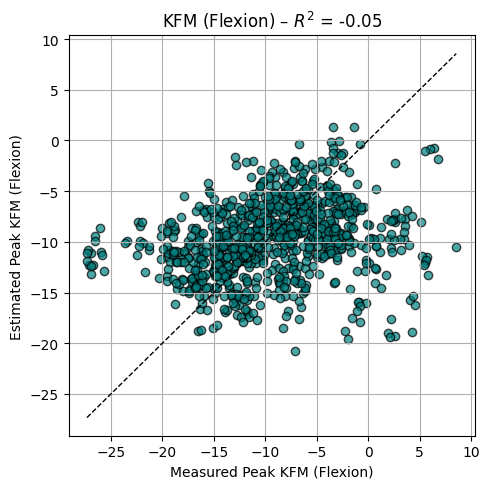

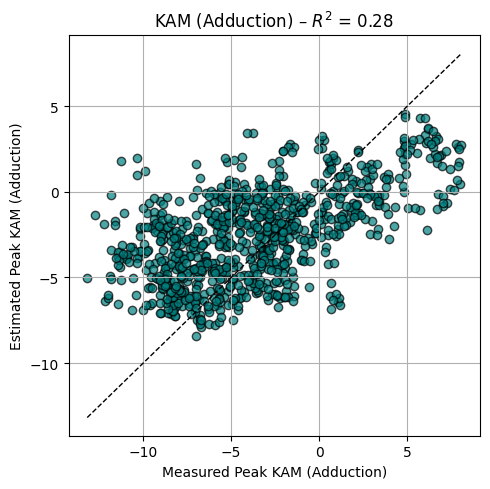

In [4]:
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Load your Excel file
file_path = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\anglepyramidCNNOPT\IWALQQ_1st_correction\angle\TruePredDiff.xlsx"
df_true_X = pd.read_excel(file_path, sheet_name="true_X")
df_pred_X = pd.read_excel(file_path, sheet_name="pred_X")
df_true_Y = pd.read_excel(file_path, sheet_name="true_Y")
df_pred_Y = pd.read_excel(file_path, sheet_name="pred_Y")

# Function to extract peak values (KFM = max, KAM = min)
def get_peak_values(df, mode='max'):
    peaks = []
    for col in df.columns:
        series = df[col].astype(float).dropna()
        if mode == 'max':
            idx = argrelextrema(series.values, np.greater_equal, order=20)[0]
            peak = series.iloc[idx].max() if len(idx) > 0 else 0
        elif mode == 'min':
            idx = argrelextrema(series.values, np.less_equal, order=20)[0]
            peak = series.iloc[idx].min() if len(idx) > 0 else 0
        peaks.append(peak)
    return np.array(peaks)

# Extract peak values
true_kfm_peaks = get_peak_values(df_true_X, mode='max')
pred_kfm_peaks = get_peak_values(df_pred_X, mode='max')
true_kam_peaks = get_peak_values(df_true_Y, mode='min')
pred_kam_peaks = get_peak_values(df_pred_Y, mode='min')

# Function to plot measured vs predicted
def plot_scatter(true_vals, pred_vals, label):
    r2 = r2_score(true_vals, pred_vals)
    plt.figure(figsize=(5,5))
    plt.scatter(true_vals, pred_vals, alpha=0.7, color='teal', edgecolors='k')
    plt.plot([min(true_vals), max(true_vals)],
             [min(true_vals), max(true_vals)], 'k--', linewidth=1)
    plt.xlabel(f"Measured Peak {label}")
    plt.ylabel(f"Estimated Peak {label}")
    plt.title(f"{label} – $R^2$ = {r2:.2f}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot both
plot_scatter(true_kfm_peaks, pred_kfm_peaks, "KFM (Flexion)")
plot_scatter(true_kam_peaks, pred_kam_peaks, "KAM (Adduction)")


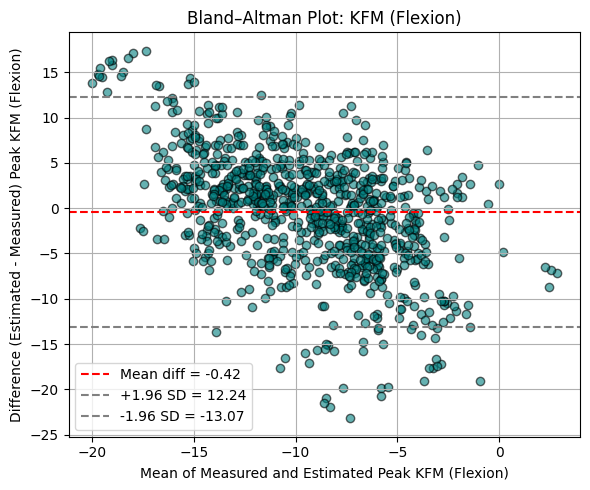

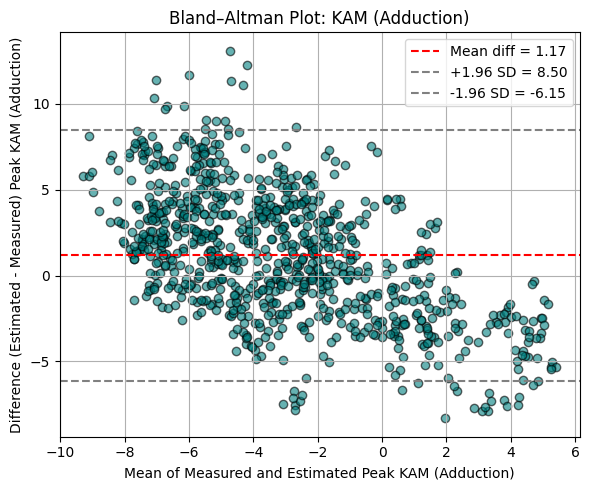

In [5]:
def plot_bland_altman(true_vals, pred_vals, label):
    import matplotlib.pyplot as plt
    import numpy as np

    true_vals = np.asarray(true_vals)
    pred_vals = np.asarray(pred_vals)

    mean_vals = (true_vals + pred_vals) / 2
    diff_vals = pred_vals - true_vals  # difference = predicted - true

    mean_diff = np.mean(diff_vals)
    std_diff = np.std(diff_vals)

    loa_upper = mean_diff + 1.96 * std_diff
    loa_lower = mean_diff - 1.96 * std_diff

    plt.figure(figsize=(6, 5))
    plt.scatter(mean_vals, diff_vals, alpha=0.6, edgecolors='k', color='teal')
    plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean diff = {mean_diff:.2f}')
    plt.axhline(loa_upper, color='gray', linestyle='--', label=f'+1.96 SD = {loa_upper:.2f}')
    plt.axhline(loa_lower, color='gray', linestyle='--', label=f'-1.96 SD = {loa_lower:.2f}')
    plt.xlabel(f"Mean of Measured and Estimated Peak {label}")
    plt.ylabel(f"Difference (Estimated - Measured) Peak {label}")
    plt.title(f"Bland–Altman Plot: {label}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_bland_altman(true_kfm_peaks, pred_kfm_peaks, "KFM (Flexion)")
plot_bland_altman(true_kam_peaks, pred_kam_peaks, "KAM (Adduction)")
